# Vigere brute Force

In [1]:
import os

# Obtener el directorio actual en Jupyter Notebook
directorio_actual = os.getcwd()

# Buscar el directorio raíz "Cryptography"
while not os.path.basename(directorio_actual) == "Cryptography":
    directorio_actual = os.path.dirname(directorio_actual)  # Retroceder un nivel

# Construir la ruta del archivo cifrado
ruta_archivo = os.path.join(directorio_actual, "Cifrados", "vigenere.txt")

# Verificar si el archivo existe antes de abrirlo
if os.path.exists(ruta_archivo):
    with open(ruta_archivo, "r", encoding="utf-8") as file:
        mensaje_cifrado = file.read().strip().upper()
    print(f"Archivo cargado desde: {ruta_archivo}")
else:
    print(f"❌ Error: No se encontró el archivo en {ruta_archivo}")

Archivo cargado desde: /Users/mvrcentes/Library/CloudStorage/OneDrive-UVG/Documentos/Semestre_9/Cryptography/Cifrados/vigenere.txt


In [40]:
import matplotlib.pyplot as plt
from collections import Counter
from prettytable import PrettyTable
from colorama import init, Fore, Style

# Inicializar colorama para colores en consola
init(autoreset=True)

# 📌 Definir el alfabeto español
# Definir el alfabeto en español (incluyendo la "Ñ")
ALFABETO = "ABCDEFGHIJKLMNÑOPQRSTUVWXYZ"

# Distribución teórica de frecuencias de letras en español (%)
import numpy as np

# 📌 Definir el alfabeto español con la "Ñ"
ALFABETO = "ABCDEFGHIJKLMNÑOPQRSTUVWXYZ"
LONG_ALFABETO = len(ALFABETO)

# 📌 Distribución teórica de frecuencias en español como un array de NumPy
DISTRIBUCION_TEORICA = np.array([
    12.53, 1.42, 4.68, 5.86, 13.68, 0.69, 1.01, 0.70, 6.25, 0.44, 0.02, 4.97, 3.15, 
    6.71, 0.31, 8.68, 2.51, 0.88, 6.87, 7.98, 4.63, 3.93, 0.90, 0.01, 0.22, 0.90, 0.52
])

print("📌 Distribución teórica definida correctamente.")


ciphertext = mensaje_cifrado.strip().upper()

📌 Distribución teórica definida correctamente.


## Calcular la frecuencia observable

In [18]:
def analizar_frecuencia(texto):
    """Calcula la frecuencia de letras en el texto cifrado."""
    total = len(texto)
    frecuencia = Counter(texto)

    # Filtrar solo letras del alfabeto español
    frecuencia_filtrada = {letra: (frecuencia[letra] / total) * 100 for letra in DISTRIBUCION_TEORICA.keys() if letra in frecuencia}
    
    return frecuencia_filtrada

# Calcular la frecuencia observada
frecuencia_observada = analizar_frecuencia(mensaje_cifrado)

In [41]:
from collections import Counter
from prettytable import PrettyTable
from colorama import init, Fore

# Inicializar colorama para colores en consola
init(autoreset=True)

def analizar_frecuencia(texto):
    """Calcula la frecuencia de letras en el texto cifrado."""
    total = len(texto)
    frecuencia = Counter(texto)

    # Filtrar solo letras del alfabeto español
    frecuencia_filtrada = {letra: (frecuencia[letra] / total) * 100 for letra in ALFABETO if letra in frecuencia}
    
    return frecuencia_filtrada

# Calcular la frecuencia observada
frecuencia_observada = analizar_frecuencia(mensaje_cifrado)

# Crear tabla de frecuencias
tabla_frecuencia = PrettyTable(["Letra", "Frecuencia Observada (%)", "Frecuencia Teórica (%)", "Diferencia (%)"])

for letra in sorted(frecuencia_observada.keys(), key=lambda x: frecuencia_observada[x], reverse=True):
    teorica = DISTRIBUCION_TEORICA[ALFABETO.index(letra)]
    observada = frecuencia_observada[letra]
    diferencia = round(abs(teorica - observada), 2)
    tabla_frecuencia.add_row([letra, round(observada, 2), teorica, diferencia])

print(f"{Fore.CYAN}📊 Comparación de Frecuencias en el Mensaje Cifrado")
print(tabla_frecuencia)

📊 Comparación de Frecuencias en el Mensaje Cifrado
+-------+--------------------------+------------------------+----------------+
| Letra | Frecuencia Observada (%) | Frecuencia Teórica (%) | Diferencia (%) |
+-------+--------------------------+------------------------+----------------+
|   S   |           7.71           |          7.98          |      0.27      |
|   A   |           6.86           |         12.53          |      5.67      |
|   R   |           6.77           |          6.87          |      0.1       |
|   E   |           6.2            |         13.68          |      7.48      |
|   N   |           6.02           |          6.71          |      0.69      |
|   T   |           5.64           |          4.63          |      1.01      |
|   C   |           5.36           |          4.68          |      0.68      |
|   O   |           5.26           |          8.68          |      3.42      |
|   I   |           4.89           |          6.25          |      1.36      |
|

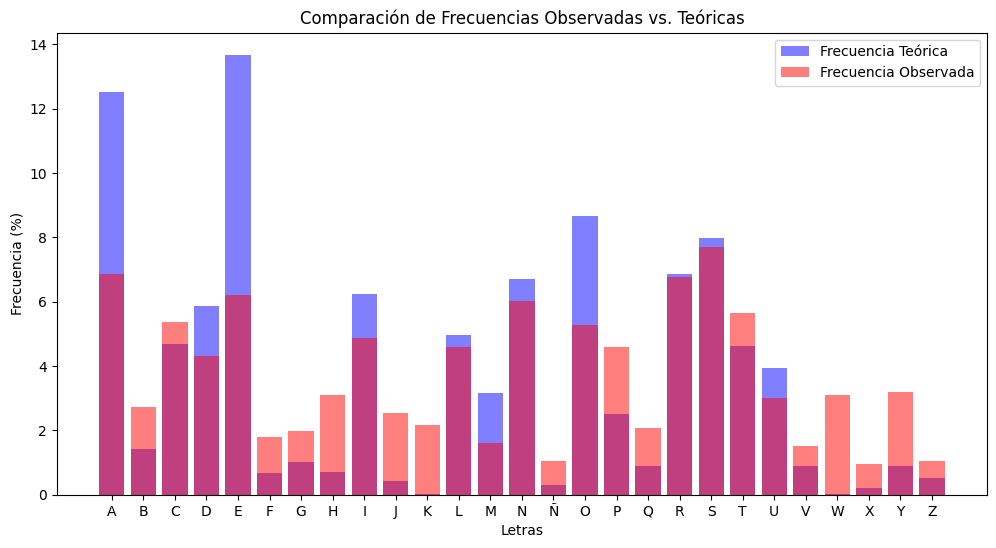

In [42]:
import matplotlib.pyplot as plt

def graficar_frecuencias(frecuencia_observada):
    """Genera un gráfico de barras comparando frecuencias observadas y teóricas."""
    letras = list(ALFABETO)
    valores_teoricos = DISTRIBUCION_TEORICA
    valores_observados = [frecuencia_observada.get(l, 0) for l in letras]

    plt.figure(figsize=(12, 6))
    plt.bar(letras, valores_teoricos, alpha=0.5, label="Frecuencia Teórica", color="blue")
    plt.bar(letras, valores_observados, alpha=0.5, label="Frecuencia Observada", color="red")
    
    plt.xlabel("Letras")
    plt.ylabel("Frecuencia (%)")
    plt.title("Comparación de Frecuencias Observadas vs. Teóricas")
    plt.legend()
    plt.show()

graficar_frecuencias(frecuencia_observada)

## Metodología 

Explicación del Método: Ataque Basado en Frecuencias

Este método es una técnica avanzada que se basa únicamente en estadísticas para recuperar la clave y el texto plano, sin necesidad de ataques de fuerza bruta. Los pasos principales son:

1. Detección del período de la clave:
	* Se usa el índice de coincidencia para determinar la repetición de patrones en el texto cifrado.
	* En este caso, se encontró que la clave tiene una longitud de 18.
2.	Construcción de tablas de frecuencia:
	* Se divide el texto cifrado en 18 segmentos (uno por cada posición de la clave).
	* Se calcula la frecuencia de cada letra en cada segmento.
3.	Determinación de los desplazamientos correctos:
	* Se comparan las distribuciones de frecuencia con las del idioma español.
	* Se rotan las tablas de cada segmento hasta encontrar la mejor coincidencia con las frecuencias teóricas.
	* Para medir la similitud, se usa el coseno del ángulo entre los vectores de frecuencias.
4.	Reconstrucción de la clave y descifrado:
	* Al encontrar los desplazamientos correctos, podemos determinar la clave completa.
	* Luego, simplemente aplicamos la inversa del cifrado de Vigenère para recuperar el texto original.

In [43]:
def indice_coincidencia(texto):
    frecuencia = Counter(texto)
    N = len(texto)
    ic = sum(f * (f - 1) for f in frecuencia.values()) / (N * (N - 1))
    return ic

print(f"🔍 Índice de coincidencia del mensaje: {indice_coincidencia(mensaje_cifrado):.4f}")

🔍 Índice de coincidencia del mensaje: 0.0467


In [44]:
def estimar_longitud_clave(texto):
    max_longitud = 20  # Limitar el rango de prueba
    ics = []
    
    for m in range(1, max_longitud + 1):
        slices = [texto[i::m] for i in range(m)]
        promedio_ic = sum(indice_coincidencia(s) for s in slices) / m
        ics.append((m, promedio_ic))

    ics.sort(key=lambda x: x[1], reverse=True)
    mejor_longitud = ics[0][0]  # Tomamos la mejor estimación
    
    print(f"🔑 Longitud estimada de la clave: {mejor_longitud}")
    return mejor_longitud

longitud_clave = estimar_longitud_clave(mensaje_cifrado)

🔑 Longitud estimada de la clave: 18


In [45]:
def encontrar_clave(texto, longitud_clave):
    slices = [texto[i::longitud_clave] for i in range(longitud_clave)]
    clave = []
    
    for grupo in slices:
        frecuencias = np.zeros(LONG_ALFABETO)

        for letra in grupo:
            if letra in ALFABETO:
                frecuencias[ALFABETO.index(letra)] += 1

        # Normalizar la frecuencia
        frecuencias = frecuencias / len(grupo)

        # Encontrar el mejor shift usando el coseno del ángulo
        mejores_shifts = []
        for shift in range(LONG_ALFABETO):
            rotada = np.roll(frecuencias, -shift)
            similitud = np.dot(rotada, DISTRIBUCION_TEORICA) / (np.linalg.norm(rotada) * np.linalg.norm(DISTRIBUCION_TEORICA))
            mejores_shifts.append((shift, similitud))

        # Tomar el shift con mejor ajuste
        mejores_shifts.sort(key=lambda x: x[1], reverse=True)
        mejor_shift = mejores_shifts[0][0]

        clave.append(ALFABETO[mejor_shift])

    clave_encontrada = "".join(clave)
    print(f"🔑 Clave encontrada: {clave_encontrada}")
    return clave_encontrada

clave_encontrada = encontrar_clave(mensaje_cifrado, longitud_clave)

🔑 Clave encontrada: PAYASOPAYASOPAYASO


In [46]:
def descifrar_vigenere(texto_cifrado, clave):
    texto_descifrado = []
    clave_expandida = (clave * (len(texto_cifrado) // len(clave))) + clave[:len(texto_cifrado) % len(clave)]

    for i, letra in enumerate(texto_cifrado):
        if letra in ALFABETO:
            pos_letra = ALFABETO.index(letra)
            pos_clave = ALFABETO.index(clave_expandida[i])
            nueva_pos = (pos_letra - pos_clave) % LONG_ALFABETO
            texto_descifrado.append(ALFABETO[nueva_pos])
        else:
            texto_descifrado.append(letra)

    return "".join(texto_descifrado)

texto_descifrado = descifrar_vigenere(mensaje_cifrado, clave_encontrada)
print("\n🔓 Texto Descifrado:")
print(texto_descifrado)


🔓 Texto Descifrado:
AUNQUEELERRORHEARTBLEEDSEHASOLUCIONADOSIEMPREHAYUNANUEVAAMENAZAENELHORIZONTEHOYLACUANTICAESESAAMENAZAQUEPUEDEATRAVESARTODASNUESTRASDEFENSASANTESDEQUETODOESTEPERDIDODEBEMOSADOPTARLACRIPTOAGILIDADPARADEFENDERNOSDISPONIBLEENLASPRINCIPALESSOLUCIONESDECRIPTOGRAFIAPOSCUANTICAPQCDELAACTUALIDADLAEVIDENCIADELAAMENAZAINMINENTEDELACOMPUTACIONCUANTICAYAESTAAQUIESPECIALMENTECONTECNICASCOMOSTORENOWDECRYPTLATERSNDLQUEYAESTANENJUEGOSNDLESUNMETODOENELQUESEROBANDATOSCIFRADOSYSEALMACENANHASTAQUELOSPIRATASINFORMATICOSPUEDANDESCIFRARLOSMASTARDECONUNACOMPUTADORACUANTICAESTOSIGNIFICAUNAAMENAZAINMINENTELOSDATOSCIFRADOSSEGONLOSESTANDARESACTUALESPEROALMACENADOSPARAUNDESCIFRADOFUTUROESTARANENRIESGOYAQUELASCOMPUTADORASCUANTICASEVENTUALMENTEROMPERANLOSMETODOSDECIFRADOACTUALESPORLOTANTOSNDLESUNABOMBADETIEMPOYUNCLARORECORDATORIODELAURGENCIADEACTUALIZARNUESTROSMETODOSDECIFRADOPARAQUESEANSEGUROSPARALACOMPUTACIONCUANTICAELENFOQUEPQCABORDALANECESIDADDECRIPTOAGILIDADCONVULNERABILIDADESCOMOSNDLQUEPRES

## Conclusión

se determinó que la longitud estimada de la clave es 18, lo que nos permitió segmentar el mensaje cifrado en grupos de caracteres según este periodo. Luego, al comparar las frecuencias de cada segmento con las distribuciones teóricas del idioma español, logramos determinar los desplazamientos correctos y reconstruir la clave.

## Referencias 

https://www.cipherchallenge.org/wp-content/uploads/2020/12/Five-ways-to-crack-a-Vigenere-cipher.pdf

GPT